In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Initialization

Define the true values of the parameters for the simulation. Then, generate 50 random locations, and random noise. define the real curve and add the noise factors

Text(0, 0.5, 'y')

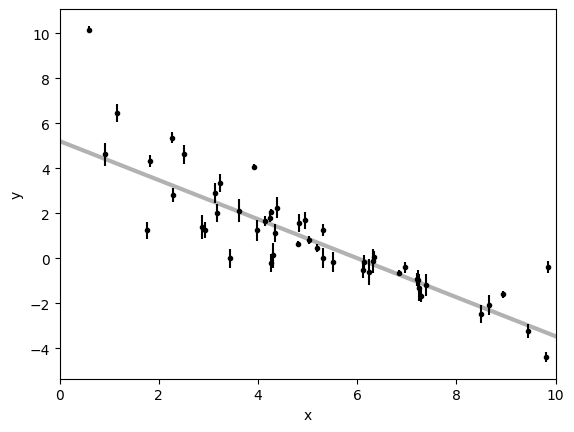

In [9]:
np.random.seed(123)

# Choose the "true" parameters.
m_true = -0.8673
b_true = 5.213
f_true = 0.534

# Generate some synthetic data from the model.
N = 50
x = np.sort(10 * np.random.rand(N))
yerr = 0.1 + 0.5 * np.random.rand(N)
y = m_true * x + b_true
y += np.abs(f_true * y) * np.random.randn(N)
y += yerr * np.random.randn(N)

plt.errorbar(x, y, yerr=yerr, fmt=".k", capsize=0)
x0 = np.linspace(0, 10, 500)
plt.plot(x0, m_true * x0 + b_true, "k", alpha=0.3, lw=3)
plt.xlim(0, 10)
plt.xlabel("x")
plt.ylabel("y")

## Likelihood and prior
Define the likelihood function, with a Gaussian shape in the model-to-data hypersurface. Define the prior to be uniform in some intervals around the real values. Finally, the posterior is given by Bayes' Theorem.

In [37]:
def log_likelihood(theta, x, y, yerr):
    m, b, log_f = theta
    model = m * x + b
    sigma2 = yerr**2 + model**2 * np.exp(2 * log_f)
    return -0.5 * np.sum((y - model) ** 2 / sigma2 + np.log(sigma2))

def log_prior(theta):
    m, b, log_f = theta
    if -5.0 < m < 0.5 and 0.0 < b < 10.0 and -10.0 < log_f < 1.0:
        return -np.log(5.5) - np.log(10.0) - np.log(11.0)  # log of the prior volume
    return -np.inf

def log_probability(theta, x, y, yerr):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, x, y, yerr)

## Least squares optimization

Define a Vandermonde matrix $A$ for the $x$ data, and then the covariance matrix from the transformation of the diagonal error matrix $C$, namely $A^T C A$. Then, solve the data problem.

Least-squares estimates:
m = -1.131 ± 0.016
b = 7.083 ± 0.091


Text(0, 0.5, 'y')

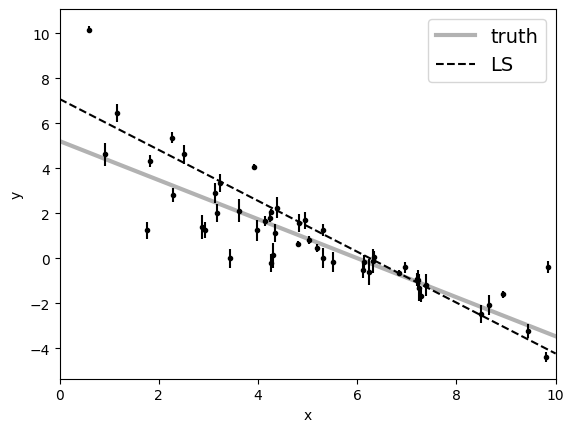

In [38]:
A = np.vander(x, 2)
C = np.diag(yerr * yerr)
ATA = np.dot(A.T, A / (yerr**2)[:, None])
cov = np.linalg.inv(ATA)
w = np.linalg.solve(ATA, np.dot(A.T, y / yerr**2))
print("Least-squares estimates:")
print("m = {0:.3f} ± {1:.3f}".format(w[0], np.sqrt(cov[0, 0])))
print("b = {0:.3f} ± {1:.3f}".format(w[1], np.sqrt(cov[1, 1])))

plt.errorbar(x, y, yerr=yerr, fmt=".k", capsize=0)
plt.plot(x0, m_true * x0 + b_true, "k", alpha=0.3, lw=3, label="truth")
plt.plot(x0, np.dot(np.vander(x0, 2), w), "--k", label="LS")
plt.legend(fontsize=14)
plt.xlim(0, 10)
plt.xlabel("x")
plt.ylabel("y")

## Determination via the optimization of the likelihood

Here we apply the minimization of the likelihood to obtain the optimal parameters. We apply a random guess around the real values.

Maximum likelihood estimates:
m = -0.859
b = 5.240
f = 0.502


Text(0, 0.5, 'y')

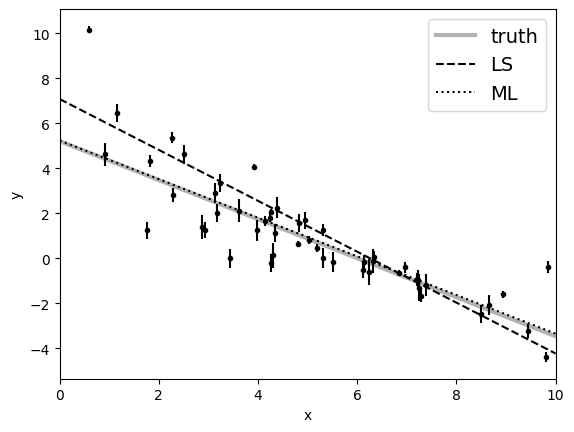

In [39]:
from scipy.optimize import minimize

np.random.seed(42)
nll = lambda *args: -log_likelihood(*args)
initial = np.array([m_true, b_true, np.log(f_true)]) + 0.1 * np.random.randn(3)
soln = minimize(nll, initial, args=(x, y, yerr))
m_ml, b_ml, log_f_ml = soln.x

print("Maximum likelihood estimates:")
print("m = {0:.3f}".format(m_ml))
print("b = {0:.3f}".format(b_ml))
print("f = {0:.3f}".format(np.exp(log_f_ml)))

plt.errorbar(x, y, yerr=yerr, fmt=".k", capsize=0)
plt.plot(x0, m_true * x0 + b_true, "k", alpha=0.3, lw=3, label="truth")
plt.plot(x0, np.dot(np.vander(x0, 2), w), "--k", label="LS")
plt.plot(x0, np.dot(np.vander(x0, 2), [m_ml, b_ml]), ":k", label="ML")
plt.legend(fontsize=14)
plt.xlim(0, 10)
plt.xlabel("x")
plt.ylabel("y")

## MCMC determination of the parameters

We initialize the chain walkers with a Gaussian ball centered around the maximum likelihood result (it seems to be a suitable initial guess). We run 5000 MCMC.

In [40]:
import emcee

pos = soln.x + 1e-4 * np.random.randn(32, 3)
nwalkers, ndim = pos.shape

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(x, y, yerr)
)
sampler.run_mcmc(pos, 5000, progress=True)

You must install the tqdm library to use progress indicators with emcee


State([[-0.90391575  5.62439218 -0.60790992]
 [-0.96437489  5.80891986 -0.85430041]
 [-0.81260215  4.84149574 -0.58596886]
 [-0.88742617  5.51705245 -0.56676859]
 [-0.9233447   5.55530158 -0.70245895]
 [-0.84716749  5.14039348 -0.81138402]
 [-0.83732743  5.13480875 -0.73727242]
 [-0.79064196  4.96578798 -0.76780944]
 [-0.88848183  5.35939303 -0.44778701]
 [-0.88829038  5.36019964 -0.83065464]
 [-0.88410524  5.33331268 -0.43630994]
 [-0.94366292  5.56322782 -0.4976668 ]
 [-0.92983561  5.58782269 -0.80125302]
 [-0.84169876  5.11849282 -0.78787149]
 [-0.81058256  4.98257847 -0.60980443]
 [-0.83358963  5.03155615 -0.57305123]
 [-0.89444616  5.37324827 -0.64337755]
 [-0.87891106  5.25669231 -0.59293565]
 [-0.87617357  5.5036782  -0.57147523]
 [-0.85376303  5.17066976 -0.691761  ]
 [-0.84658599  5.09445586 -0.56024663]
 [-0.92743592  5.65442694 -0.63264513]
 [-0.90789043  5.58486503 -0.604472  ]
 [-0.82907768  5.16277227 -0.42212272]
 [-0.88773112  5.47642929 -0.7572863 ]
 [-0.84965851  5.18

Text(0.5, 0, 'step number')

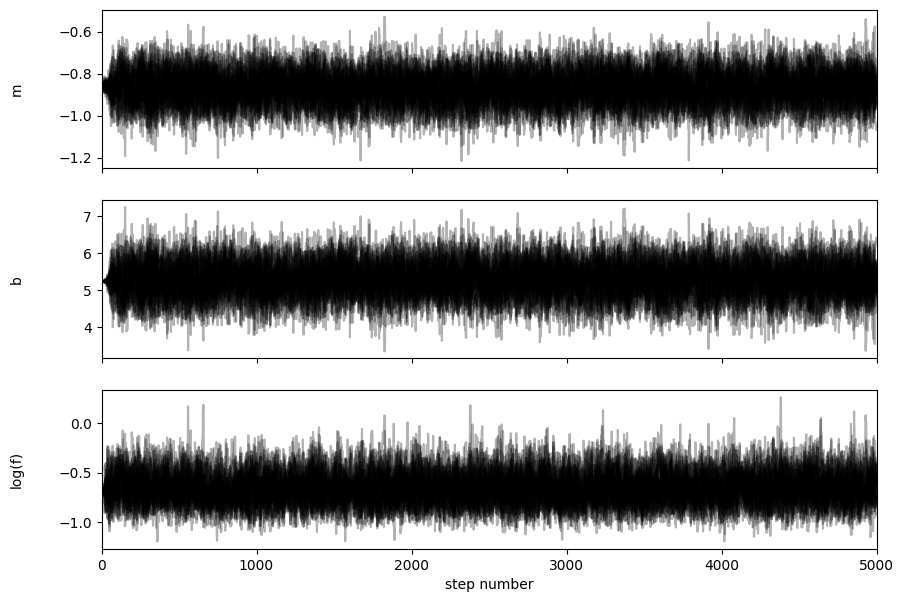

In [41]:
fig, axes = plt.subplots(3, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = ["m", "b", "log(f)"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number")

In [42]:
flat_samples = sampler.get_chain(discard=100, thin=15, flat=True)
print(flat_samples.shape)

(10432, 3)


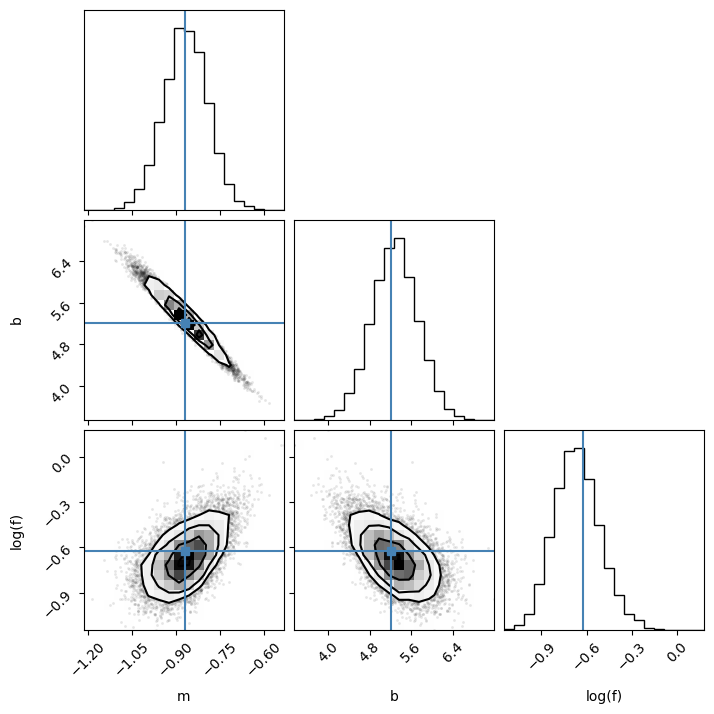

In [43]:
import corner

fig = corner.corner(
    flat_samples, labels=labels, truths=[m_true, b_true, np.log(f_true)]
)

In [44]:
mcmc_m = np.percentile(flat_samples[:, 0], [16, 50, 84])
mcmc_b = np.percentile(flat_samples[:, 1], [16, 50, 84])
mcmc_f = np.percentile(flat_samples[:, 2], [16, 50, 84])
q_m = np.diff(mcmc_m)
q_b = np.diff(mcmc_b)
q_f = np.diff(np.exp(mcmc_f))

print("m = " + str(round(mcmc_m[1], 3)) + " + " + str(round(q_m[1], 3)) + " - " + str(round(q_m[0], 3)))
print("b = " + str(round(mcmc_b[1], 3)) + " + " + str(round(q_b[1], 3)) + " - " + str(round(q_b[0], 3)))
print("f = " + str(round(np.exp(mcmc_f[1]), 3)) + " + " + str(round(q_f[1], 3)) + " - " + str(round(q_f[0], 3)))

m = -0.866 + 0.074 - 0.074
b = 5.285 + 0.439 - 0.439
f = 0.512 + 0.087 - 0.069
